# 1. Kütüphaneleri İçeri Aktarma
1. Numpy
2. Pandas
3. Seaborn
4. Matplatlib
5. Scipy
6. Warnings


In [2]:
# Temel kütüphaneler
import numpy as np
import pandas as pd

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# İstatistiksel testler için
from scipy.stats import shapiro, ttest_ind, f_oneway, pearsonr

# Makine öğrenmesi için sklearn kütüphanesi
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve


# Sınıflandırma modelleri
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Uyarıları kapatıyoruz
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("Hepsi Yüklendi")

Hepsi Yüklendi


# 2. Excel Tablosundaki Verilerin Yüklenmesi
Toplam 7 Tablomuz var 
1. *OrderLine*: Ürün, Miktar ve Fiyat Bilgisi
2. *Product*: Ürünün kategorisi, Maaliyeti ve Fiyat bilgisi 
3. *Promotion*: Kampanya durumları
4. *Returns*: İade Bilgileri
5. *Calendar*: Takvim ve Tatil Bilgileri
6. *Fulfillment*: Kargo ve Teslimat Bilgileri
7. *OrderHeader*: Sipariş Başlıkları

In [3]:
#Tabloların olduğu dosya yolu
dosya_yolu = 'Christmas_Retail_Sales_and_Marketing_Analysis_Dataset.xlsx'
# Pandas ile excel dosyarını okuyorum ve isimlerini tek tek değişkenlere atıyorum
order_line = pd.read_excel(dosya_yolu, sheet_name='OrderLine')
product = pd.read_excel(dosya_yolu, sheet_name='Product')
promotion = pd.read_excel(dosya_yolu, sheet_name='Promotion')
returns = pd.read_excel(dosya_yolu, sheet_name='Returns')
calendar = pd.read_excel(dosya_yolu, sheet_name='Calendar')
fulfillment = pd.read_excel(dosya_yolu, sheet_name='Fulfillment')
order_header = pd.read_excel(dosya_yolu, sheet_name='OrderHeader')

print("Tablolar Yüklendi")

Tablolar Yüklendi


# 2.1 Tabloların İncelenmesi
Sıra sıra her tablonun ilk 5 satırını inceledim


In [4]:
# OrderLine tablosu
print("ORDER LINE TABLOSU")
order_line.head()

ORDER LINE TABLOSU


,OrderLineID,OrderID,ProductID,Qty,UnitPrice,LineDiscount$,LineCost$,LineRevenue$
0,OL0000001,O000001,P001689,2,323.19,45.22,363.40,601.16
1,OL0000002,O000001,P000676,3,34.66,7.27,59.13,96.71
2,OL0000003,O000001,P000972,1,76.08,5.32,45.59,70.76
3,OL0000004,O000001,P001872,3,45.45,9.54,93.42,126.81
4,OL0000005,O000001,P001669,1,78.55,5.50,50.67,73.05


In [5]:
# Product tablosu
print("PRODUCT TABLOSU")
product.head()

PRODUCT TABLOSU


,ProductID,Category,Subcategory,StandardCost,MSRP,Vendor,SeasonalityTag
0,P000001,Sports,Cycling,154.81,241.95,VendorD,Winter
1,P000002,Books,Non-Fiction,5.42,10.36,VendorD,Evergreen
2,P000003,Beauty,Cosmetics,40.70,69.24,VendorA,Winter
3,P000004,Books,Children,31.79,52.81,VendorC,Giftable
4,P000005,Electronics,Gaming,71.59,110.37,VendorC,Winter


In [6]:
# OrderHeader tablosu
print("ORDER HEADER TABLOSU")
order_header.head()

ORDER HEADER TABLOSU


,OrderID,OrderDateTime,CustomerID,ChannelID,StoreID,PromotionID,CouponCode,PaymentType
0,O000001,2025-11-04 14:19:00,C015001,STORE,S060,PR041,BF25,Card
1,O000002,2025-11-25 02:54:00,C024674,WEB,NaN,PR040,NaN,PayPal
2,O000003,2025-12-01 23:47:00,C002255,WEB,NaN,NaN,NaN,Card
3,O000004,2025-12-16 23:50:00,C007868,WEB,NaN,PR023,SAVE10,Card
4,O000005,2025-11-02 14:04:00,C005260,WEB,NaN,PR059,NaN,Card


In [7]:
# Fulfillment tablosunu inceleyelim
print("FULFILLMENT TABLOSU")
fulfillment.head()

FULFILLMENT TABLOSU


,ShipmentID,OrderID,WarehouseID,Carrier,ServiceLevel,PromisedDate,ShipDate,DeliveryDate,ShipCost$,DeliveryStatus
0,SH000001,O000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
1,SH000002,O000002,W03,UPS,Std,2025-11-30,2025-11-27,2025-12-01,8.00,Late
2,SH000003,O000003,W04,UPS,Std,2025-12-06,2025-12-03,2025-12-09,8.22,Late
3,SH000004,O000004,W01,USPS,Std,2025-12-21,2025-12-18,2025-12-25,7.97,Late
4,SH000005,O000005,W01,DHL,Std,2025-11-07,2025-11-02,2025-11-08,11.09,Late


In [8]:
# Promotion tablosunu inceleyelim
print("PROMOTION TABLOSU")
print("=" * 50)
promotion.head()

PROMOTION TABLOSU


,PromotionID,Name,CampaignType,StartDate,EndDate,TargetSegment,DiscountType,PlannedLift%,PlannedBudget
0,PR001,BF-PR001,BF,2025-12-02,2025-12-09,New Customers,Percent,24.1,981583.96
1,PR002,Holiday-PR002,Holiday,2025-12-02,2025-12-05,Loyalty,Percent,40.5,892678.22
2,PR003,BF-PR003,BF,2025-12-18,2025-12-28,Returning Customers,Price,42.0,1025388.49
3,PR004,Holiday-PR004,Holiday,2025-11-14,2025-11-17,Loyalty,BOGO,35.5,790782.09
4,PR005,BF-PR005,BF,2025-11-14,2025-11-20,Loyalty,Percent,46.6,351736.49


In [9]:
# returns tablosunu inceleyelim
print("RETURNS TABLOSU")
returns.head()

RETURNS TABLOSU


,ReturnID,OrderLineID,ReturnDate,ReasonCode,Condition,Refund$,RestockFee$,ReturnShipCost$,Disposition
0,R0000001,OL0000001,2025-11-16,Changed Mind,Damaged,589.19,4.51,7.46,Write-off
1,R0000002,OL0000003,2025-12-09,Defective,New,61.41,8.96,0.39,Resell
2,R0000003,OL0000008,2025-12-11,Changed Mind,Opened,200.27,3.72,2.20,Write-off
3,R0000004,OL0000015,2026-01-21,Late Delivery,Opened,192.96,0.97,8.05,Write-off
4,R0000005,OL0000030,2025-12-29,Wrong Size,Opened,30.63,4.13,9.87,Write-off


In [10]:
# calendar tablosunu inceleyelim
print("CALENDAR TABLOSU")
calendar.head()

CALENDAR TABLOSU


,DateKey,Date,Week,FiscalMonth,HolidayFlag,EventName
0,20251101,2025-11-01,44,FY25-11,N,NaN
1,20251102,2025-11-02,44,FY25-11,N,NaN
2,20251103,2025-11-03,45,FY25-11,N,NaN
3,20251104,2025-11-04,45,FY25-11,N,NaN
4,20251105,2025-11-05,45,FY25-11,N,NaN


# Tabloları Tek Tablo Haline Getiriyorum

In [11]:
# OrderLine ve Product tablolarıni birleştiriyorum
# ProductID uzerinden left join yaptım
df = pd.merge(order_line, product, on='ProductID', how='left')

# OrderHeader tablosunu ekliyoruz
df = pd.merge(df, order_header, on='OrderID', how='left')

# Fulfillment tablosunu ekliyorum
df = pd.merge(df, fulfillment, on='OrderID', how='left')
print("\nGerekli tablolar birleştirildi.")


Gerekli tablolar birleştirildi.


In [12]:
# Birlestirilmiş tabloloların yapısı
print(f"Toplam satir sayisi: {df.shape[0]}")
print(f"Toplam sütün sayisi: {df.shape[1]}")
print("\nSutunlar:")
print(df.columns.tolist())

Toplam satir sayisi: 182138
Toplam sütün sayisi: 30

Sutunlar:
['OrderLineID', 'OrderID', 'ProductID', 'Qty', 'UnitPrice', 'LineDiscount$', 'LineCost$', 'LineRevenue$', 'Category', 'Subcategory', 'StandardCost', 'MSRP', 'Vendor', 'SeasonalityTag', 'OrderDateTime', 'CustomerID', 'ChannelID', 'StoreID', 'PromotionID', 'CouponCode', 'PaymentType', 'ShipmentID', 'WarehouseID', 'Carrier', 'ServiceLevel', 'PromisedDate', 'ShipDate', 'DeliveryDate', 'ShipCost$', 'DeliveryStatus']


In [13]:
# Birlestirilmiş tabloloların ilk 5 satırı
df.head()

,OrderLineID,OrderID,ProductID,Qty,UnitPrice,LineDiscount$,LineCost$,LineRevenue$,Category,Subcategory,...,PaymentType,ShipmentID,WarehouseID,Carrier,ServiceLevel,PromisedDate,ShipDate,DeliveryDate,ShipCost$,DeliveryStatus
0,OL0000001,O000001,P001689,2,323.19,45.22,363.40,601.16,Books,Non-Fiction,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
1,OL0000002,O000001,P000676,3,34.66,7.27,59.13,96.71,Beauty,Cosmetics,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
2,OL0000003,O000001,P000972,1,76.08,5.32,45.59,70.76,Toys,Puzzles,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
3,OL0000004,O000001,P001872,3,45.45,9.54,93.42,126.81,Electronics,Gaming,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
4,OL0000005,O000001,P001669,1,78.55,5.50,50.67,73.05,Footwear,Boots,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late


In [14]:
# Veri tipleri
print("VERI TIPLERI")
df.dtypes

VERI TIPLERI


OrderLineID        object
OrderID            object
ProductID          object
Qty                 int64
UnitPrice         float64
LineDiscount$     float64
LineCost$         float64
LineRevenue$      float64
Category           object
Subcategory        object
StandardCost      float64
MSRP              float64
Vendor             object
SeasonalityTag     object
OrderDateTime      object
CustomerID         object
ChannelID          object
StoreID            object
PromotionID        object
CouponCode         object
PaymentType        object
ShipmentID         object
WarehouseID        object
Carrier            object
ServiceLevel       object
PromisedDate       object
ShipDate           object
DeliveryDate       object
ShipCost$         float64
DeliveryStatus     object
dtype: object

# 3. Veri Analizi(EDA)

In [15]:
# Temel istatistikler - describe() fonksiyonu
# Sayısal değerlerin ortalama, standart sapma, min, max değerleri
print("SAYISAL DEGISKENLERIN ISTATISTIKLERI")
df.describe()

SAYISAL DEGISKENLERIN ISTATISTIKLERI


,Qty,UnitPrice,LineDiscount$,LineCost$,LineRevenue$,StandardCost,MSRP,ShipCost$
count,182138.000000,182138.000000,182138.000000,182138.000000,182138.000000,182138.000000,182138.000000,182138.000000
mean,1.801024,168.758026,57.767319,184.143364,246.174710,102.258435,168.758026,11.125324
std,0.870582,95.735046,77.820564,143.016785,199.615125,56.073367,95.735046,6.915503
min,1.000000,7.020000,0.000000,5.030000,1.400000,5.030000,7.020000,0.000000
25%,1.000000,88.330000,9.530000,77.770000,101.952500,54.680000,88.330000,6.680000
50%,2.000000,165.220000,26.710000,148.520000,197.800000,101.900000,165.220000,9.790000
75%,2.000000,245.840000,73.430000,257.130000,327.570000,150.080000,245.840000,13.430000
max,4.000000,396.070000,786.960000,799.680000,1551.820000,199.920000,396.070000,35.000000


In [16]:
# Kategorik değişkenlerin istatistikleri
print("KATEGORIK DEGISKENLERIN ISTATISTIKLERI")

df.describe(include='object')

KATEGORIK DEGISKENLERIN ISTATISTIKLERI


,OrderLineID,OrderID,ProductID,Category,Subcategory,Vendor,SeasonalityTag,OrderDateTime,CustomerID,ChannelID,...,CouponCode,PaymentType,ShipmentID,WarehouseID,Carrier,ServiceLevel,PromisedDate,ShipDate,DeliveryDate,DeliveryStatus
count,182138,182138,182138,182138,182138,182138,182138,182138,182138,182138,...,104004,182138,182138,182138,182138,182138,182138,182138,182138,182138
unique,182138,45000,4000,10,30,5,3,30942,20836,3,...,4,4,45000,5,4,4,71,68,75,2
top,OL0182138,O000008,P001414,Grocery,Snacks,VendorA,Giftable,2025-12-01 01:11:00,C015010,WEB,...,HOLIDAY15,Card,SH000008,W02,DHL,Std,2025-12-03,2025-11-28,2025-12-04,Late
freq,1,6,72,19605,6762,36940,92935,50,40,108179,...,26723,126559,6,36978,46076,108299,14129,9254,7300,125219


# Eksik Veri Tespiti

In [17]:
# Eksik veri sayisi ve orani
eksik_veri = pd.DataFrame({
    'Eksik Sayisi': df.isnull().sum(), # Her sutundaki eksik veri sayisi
    'Eksik Orani (%)': (df.isnull().sum() / len(df) * 100).round(2) # Her sutundaki eksik veri oranı
})

# Sadece eksik verisi olan sütünlar
eksik_veri = eksik_veri[eksik_veri['Eksik Sayisi'] > 0].sort_values('Eksik Sayisi', ascending=False) #ascending burada küçükten büyüğe sıralama yapar

print("EKSIK VERI ANALIZI")
if len(eksik_veri) == 0:
    print("Veri setinde eksik veri bulunmamaktadir.")
else:
    print(eksik_veri)

EKSIK VERI ANALIZI
             Eksik Sayisi  Eksik Orani (%)
StoreID            136211            74.78
CouponCode          78134            42.90
PromotionID         14602             8.02


# Temel Değerler

In [18]:
# LineRevenue$ (Satis Geliri) sütünu için istatistikler
gelir = df['LineRevenue$']

print("SATIS GELIRI ISTATISTIKLERI")

print(f"Ortalama (Mean): ${gelir.mean():,.2f}") # Ortalama değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Medyan (Median): ${gelir.median():,.2f}") # Medyan değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Mod (Mode): ${gelir.mode()[0]:,.2f}") # Mod değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Standart Sapma (Std): ${gelir.std():,.2f}") # Standart sapma değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Varyans (Var): ${gelir.var():,.2f}") # Varyans değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Minimum: ${gelir.min():,.2f}") # Minimum değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Maksimum: ${gelir.max():,.2f}") # Maksimum değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Çarpıklık (Skewness): {gelir.skew():.4f}") # Çarpıklık değeri dört ondalık basamakla gösterir
print(f"Basıklık (Kurtosis): {gelir.kurtosis():.4f}") # Basıklık değeri dört ondalık basamakla gösterir

SATIS GELIRI ISTATISTIKLERI
Ortalama (Mean): $246.17
Medyan (Median): $197.80
Mod (Mode): $122.70
Standart Sapma (Std): $199.62
Varyans (Var): $39,846.20
Minimum: $1.40
Maksimum: $1,551.82
Çarpıklık (Skewness): 1.5347
Basıklık (Kurtosis): 3.0440


# 4. Görselleştirme
###   4.1 Kategorik Olanlar:  

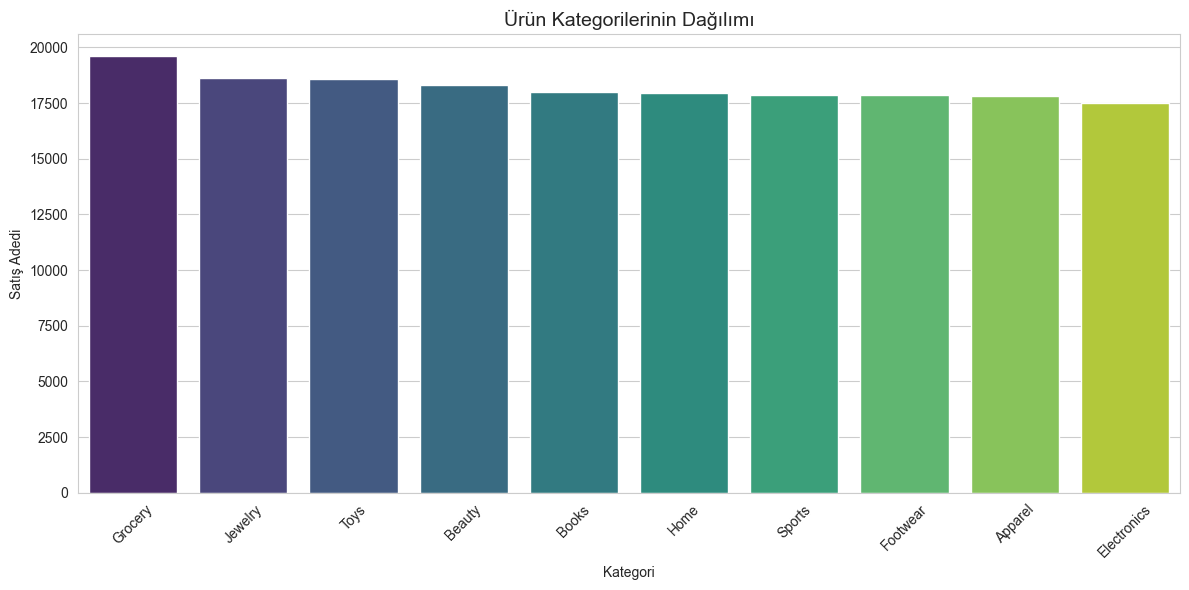

In [19]:
# Ürün kategorilerinin dağılımı
plt.figure(figsize=(12, 6))
kategori_sayilari = df['Category'].value_counts()
sns.barplot(x=kategori_sayilari.index, y=kategori_sayilari.values, palette='viridis')
plt.title('Ürün Kategorilerinin Dağılımı', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Satış Adedi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

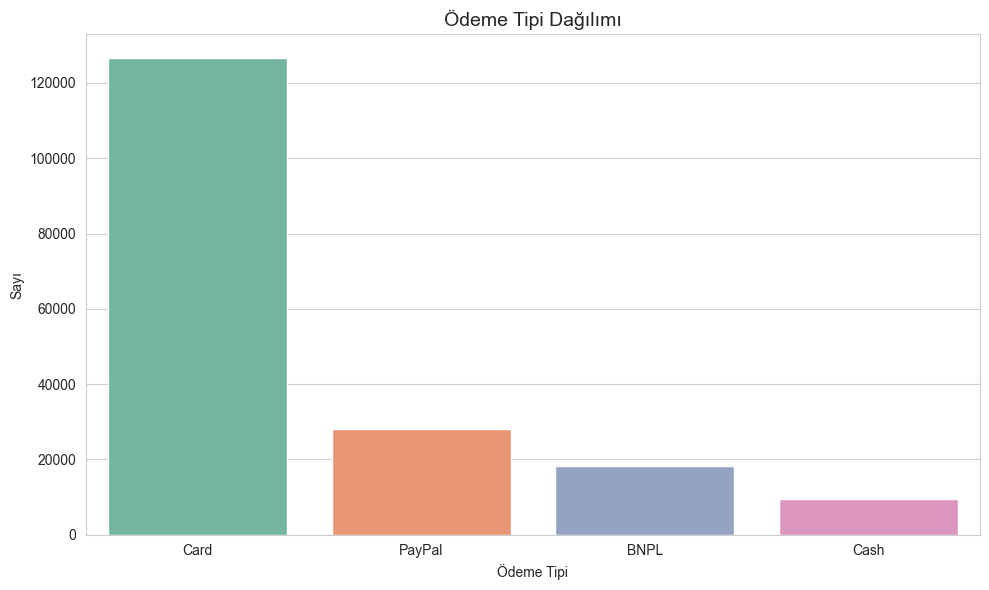

In [20]:
# Ödeme tipi dağılımı - countplot kullanımı
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentType', palette='Set2')
plt.title('Ödeme Tipi Dağılımı', fontsize=14)
plt.xlabel('Ödeme Tipi')
plt.ylabel('Sayı')
plt.tight_layout()
plt.show()

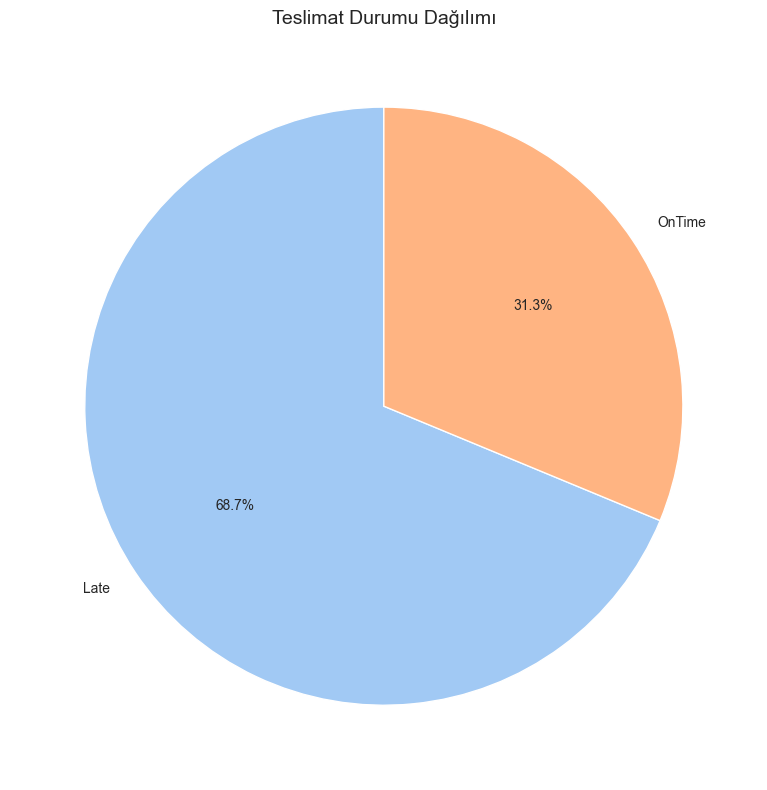

In [21]:
# Teslimat durumu dağılımı - pie chart
plt.figure(figsize=(10, 8))
teslimat_durumu = df['DeliveryStatus'].value_counts()
plt.pie(teslimat_durumu.values, labels=teslimat_durumu.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Teslimat Durumu Dağılımı', fontsize=14)
plt.tight_layout()
plt.show()

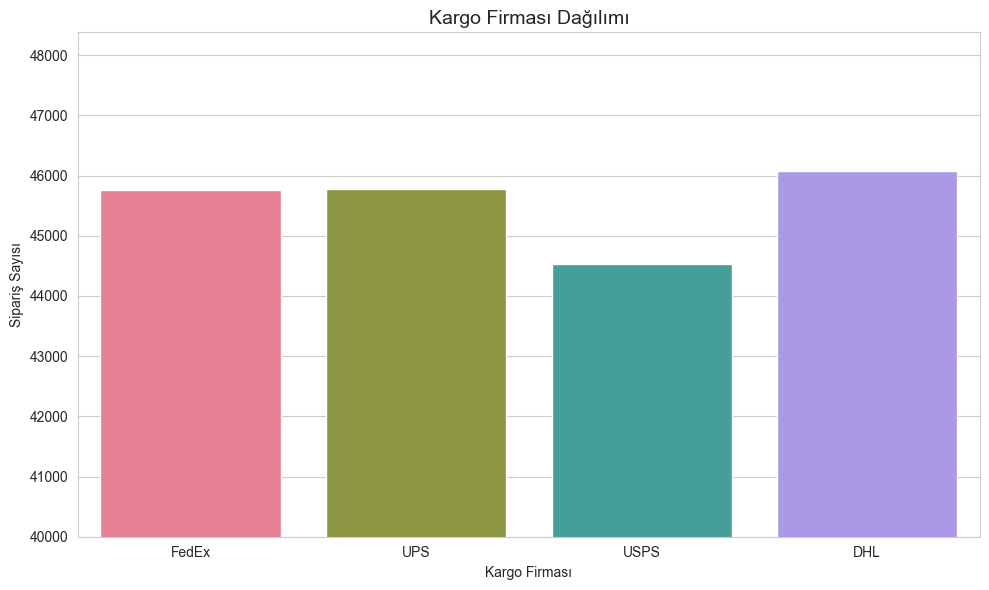

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Carrier', palette='husl')

plt.title('Kargo Firması Dağılımı', fontsize=14)
plt.xlabel('Kargo Firması')
plt.ylabel('Sipariş Sayısı')

plt.ylim(40000, None)  # Y ekseni 40.000’den başlar

plt.tight_layout()
plt.show()


### 4.2 Sayısal Olanlar

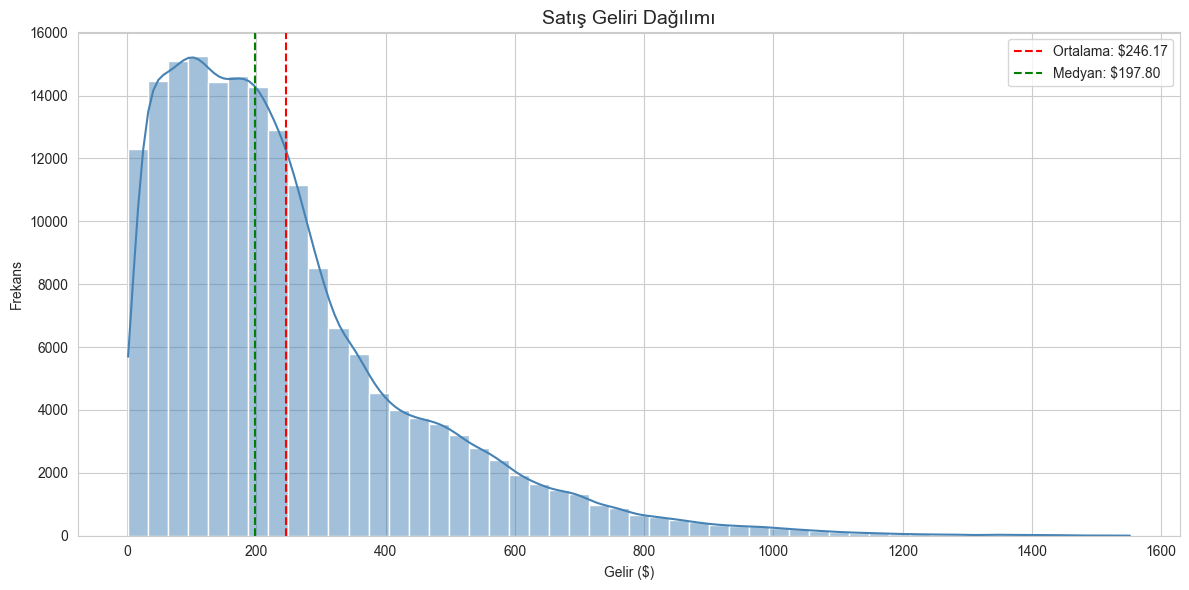

In [23]:
# Satis geliri dağılımı - histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['LineRevenue$'], kde=True, bins=50, color='steelblue') # Histogram ve KDE çizimi
plt.title('Satış Geliri Dağılımı', fontsize=14)
plt.xlabel('Gelir ($)')
plt.ylabel('Frekans')

# Ortalama ve medyan çizgileri
plt.axvline(df['LineRevenue$'].mean(), color='red', linestyle='--', label=f'Ortalama: ${df["LineRevenue$"].mean():,.2f}') # Ortalama çizgisi
plt.axvline(df['LineRevenue$'].median(), color='green', linestyle='--', label=f'Medyan: ${df["LineRevenue$"].median():,.2f}') # Medyan çizgisi
plt.legend() # Legend gösterimi
plt.tight_layout() # Layout ayarları
plt.show()

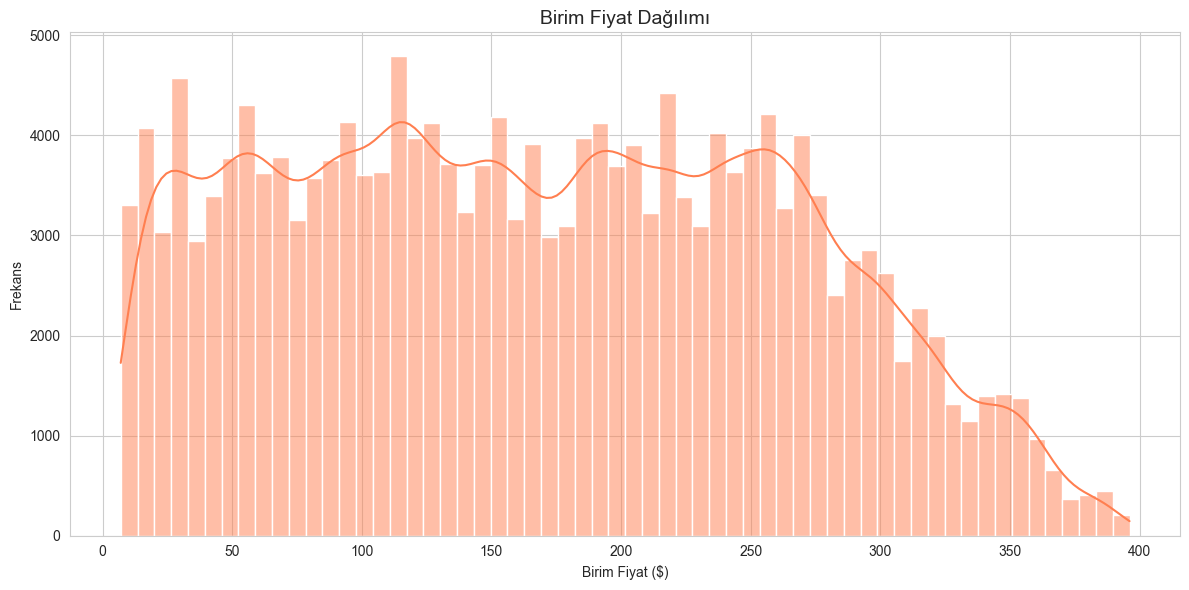

In [24]:
# Birim fiyat dağılımı - histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['UnitPrice'], kde=True, bins=60, color='coral') # Histogram ve KDE çizimi
plt.title('Birim Fiyat Dağılımı', fontsize=14)
plt.xlabel('Birim Fiyat ($)')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

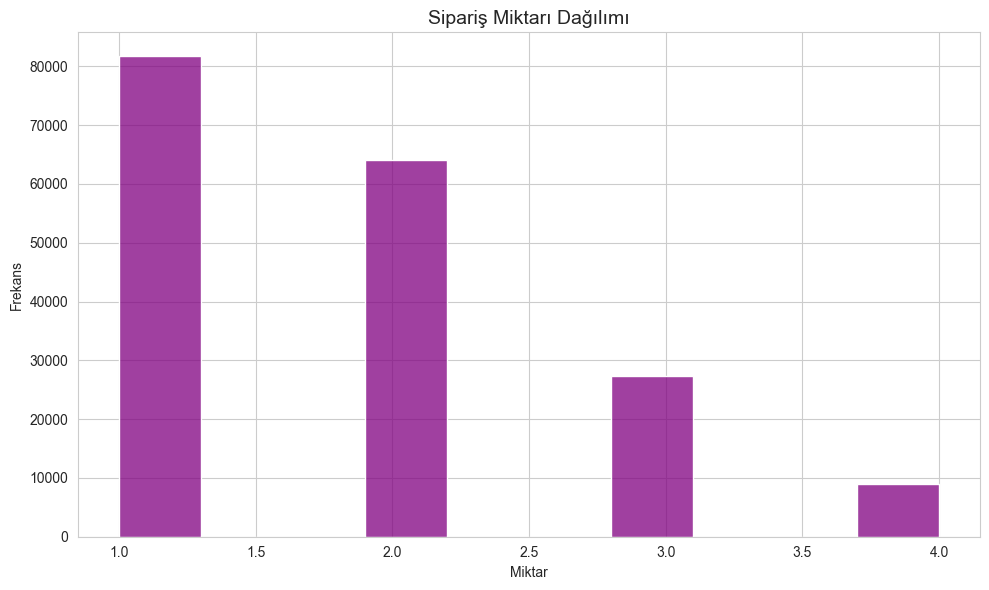

In [25]:
# Miktar dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df['Qty'], kde=False, bins=10, color='purple')
plt.title('Sipariş Miktarı Dağılımı', fontsize=14)
plt.xlabel('Miktar')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

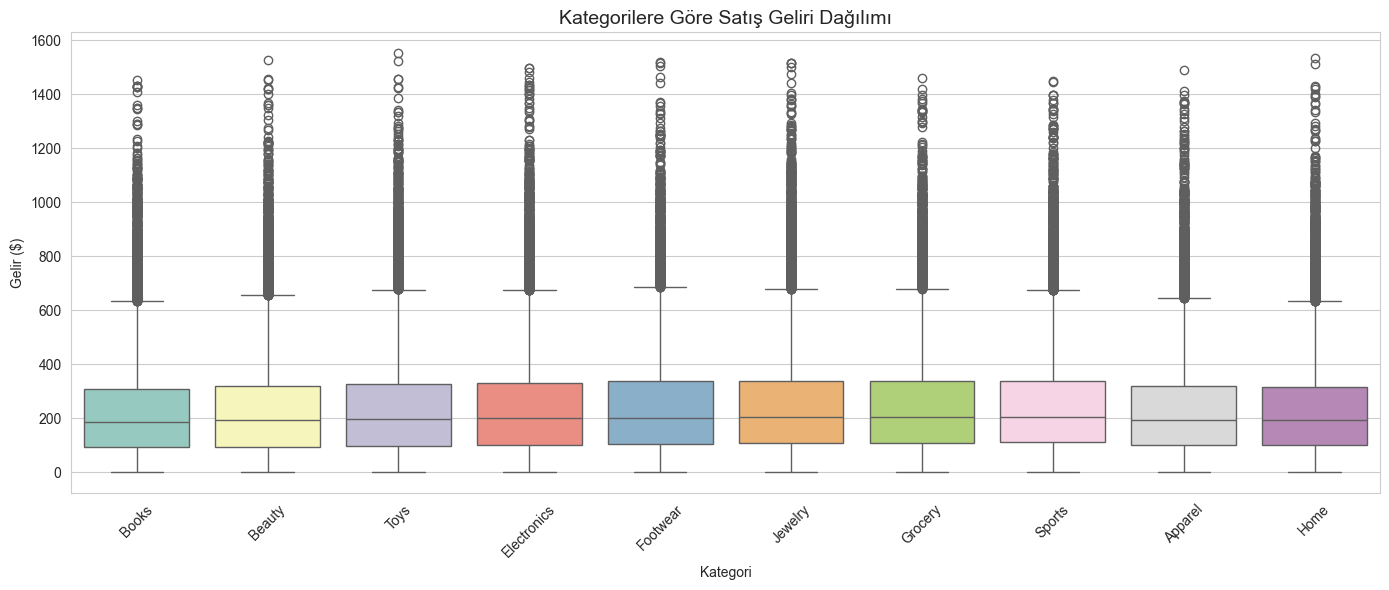

In [26]:
# Kategorilere göre gelir boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Category', y='LineRevenue$', palette='Set3')
plt.title('Kategorilere Göre Satış Geliri Dağılımı', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Gelir ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

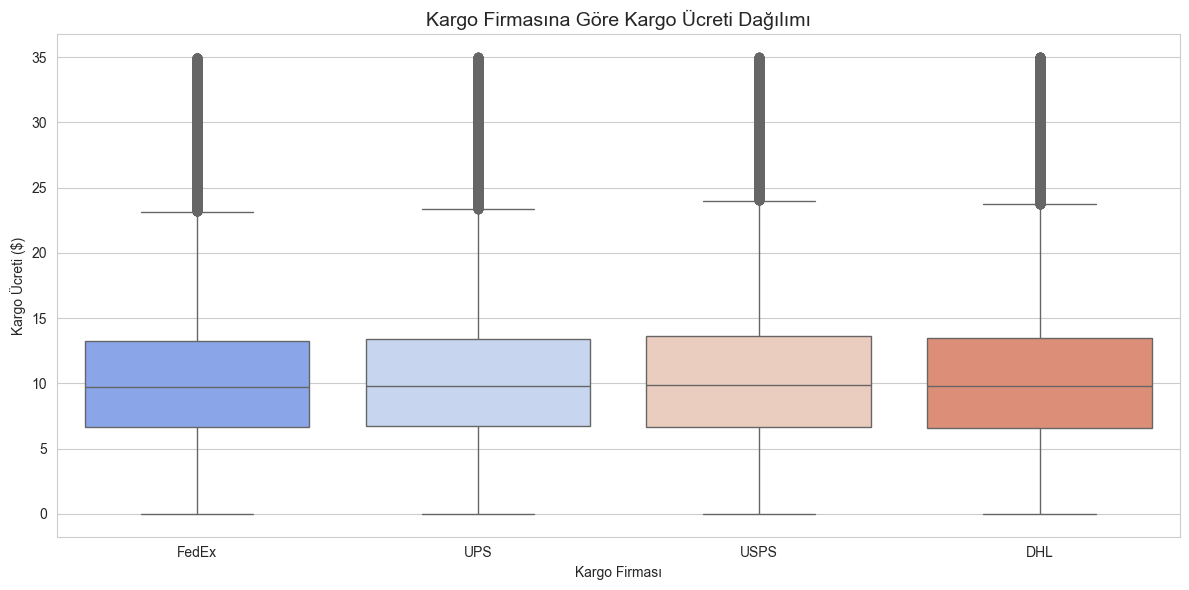

In [27]:
# Kargo firmasina göre kargo ücreti boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Carrier', y='ShipCost$', palette='coolwarm')
plt.title('Kargo Firmasına Göre Kargo Ücreti Dağılımı', fontsize=14)
plt.xlabel('Kargo Firması')
plt.ylabel('Kargo Ücreti ($)')
plt.tight_layout()
plt.show()

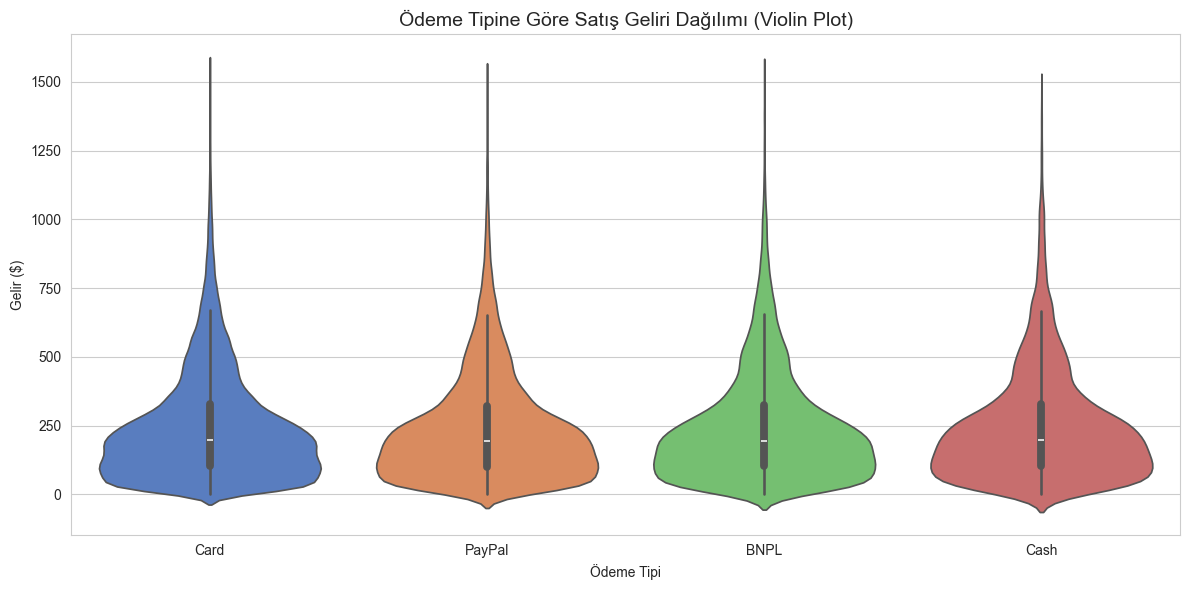

In [28]:
# Ödeme tipine göre gelir violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='PaymentType', y='LineRevenue$', palette='muted')
plt.title('Ödeme Tipine Göre Satış Geliri Dağılımı (Violin Plot)', fontsize=14)
plt.xlabel('Ödeme Tipi')
plt.ylabel('Gelir ($)')
plt.tight_layout()
plt.show()

### 4.3 Korelasyon Analizi ve Heatmap Grafikleri

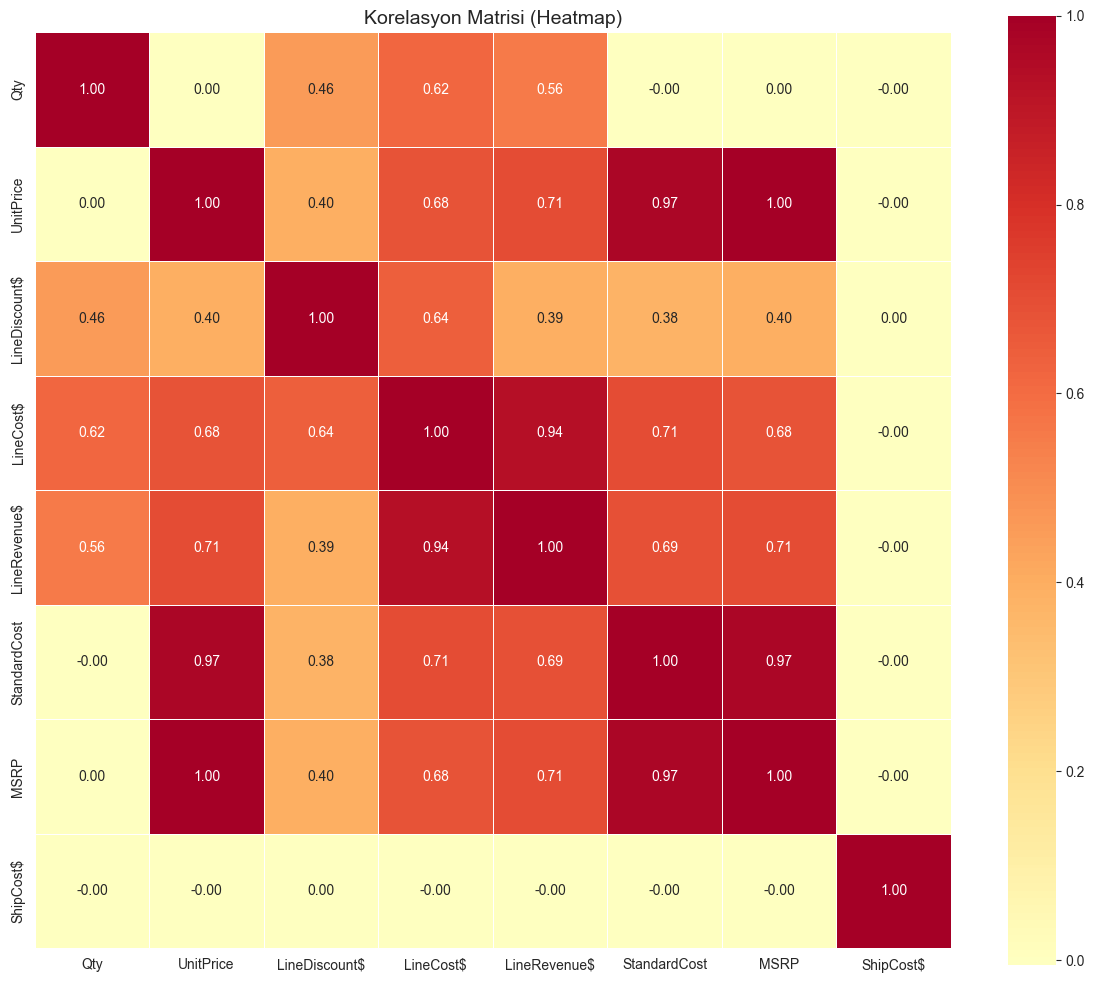

In [29]:
# Sayısal değişkenler arasındaki korelasyon
sayisal_sutunlar = ['Qty', 'UnitPrice', 'LineDiscount$', 'LineCost$', 'LineRevenue$', 
                    'StandardCost', 'MSRP', 'ShipCost$']

korelasyon = df[sayisal_sutunlar].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(korelasyon, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Korelasyon Matrisi (Heatmap)', fontsize=14)
plt.tight_layout()
plt.show()

1. Qty: Satın alınan ürün adedi
2. UnitPrice: Ürünün birim satış fiyatı
3. LineDiscount$: Sipariş satırına uygulanan toplam indirim tutarı
4. LineCost$: Sipariş satırındaki ürünlerin toplam maliyeti
5. LineRevenue$: Sipariş satırından elde edilen toplam gelir
6. StandardCost: Ürünün birim başına standart maliyeti
7. MSRP: Üretici tarafından önerilen perakende satış fiyatı
8. ShipCost$: Sipariş satırına ait kargo maliyeti


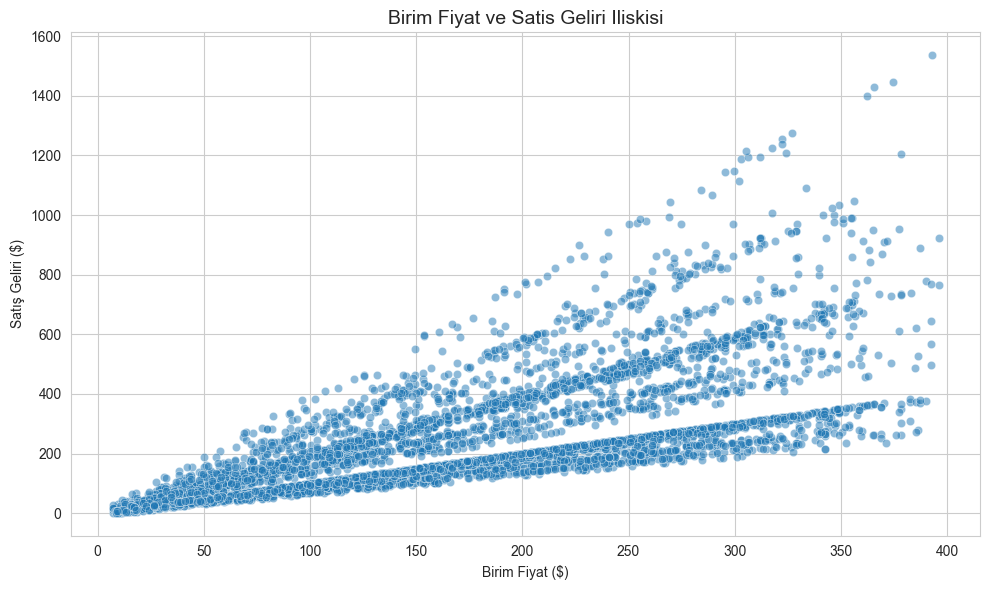

In [30]:
# Scatter plot - Birim fiyat ve Gelir ilişkisi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(5000), x='UnitPrice', y='LineRevenue$', alpha=0.5)
plt.title('Birim Fiyat ve Satis Geliri Iliskisi', fontsize=14)
plt.xlabel('Birim Fiyat ($)')
plt.ylabel('Satış Geliri ($)')
plt.tight_layout()
plt.show()

### 4.4 Gruplandırma ve Aggregation İşlemleri

In [31]:
# Kategorilere göre toplam gelir - groupby ve agg kullanimi
kategori_gelir = df.groupby('Category')['LineRevenue$'].agg(['sum', 'mean', 'count']).reset_index() #agg ile birden fazla istatistiksel özetleme yapıyoruz
kategori_gelir.columns = ['Kategori', 'Toplam Gelir', 'Ortalama Gelir', 'Satış Adedi']
kategori_gelir = kategori_gelir.sort_values('Toplam Gelir', ascending=False) #ascending burada küçükten büyüğe sıralama yapar

print("KATEGORİLERE GÖRE GELİR ANALİZİ")
kategori_gelir

KATEGORİLERE GÖRE GELİR ANALİZİ


,Kategori,Toplam Gelir,Ortalama Gelir,Satış Adedi
5,Grocery,4898149.25,249.841839,19605
7,Jewelry,4754395.83,255.064154,18640
9,Toys,4554430.44,245.138621,18579
8,Sports,4523718.05,253.174281,17868
4,Footwear,4504075.00,252.244344,17856
1,Beauty,4380488.19,239.018289,18327
3,Electronics,4368566.38,249.603838,17502
0,Apparel,4327071.42,242.698492,17829
6,Home,4306133.89,240.083290,17936
2,Books,4220740.85,234.537722,17996


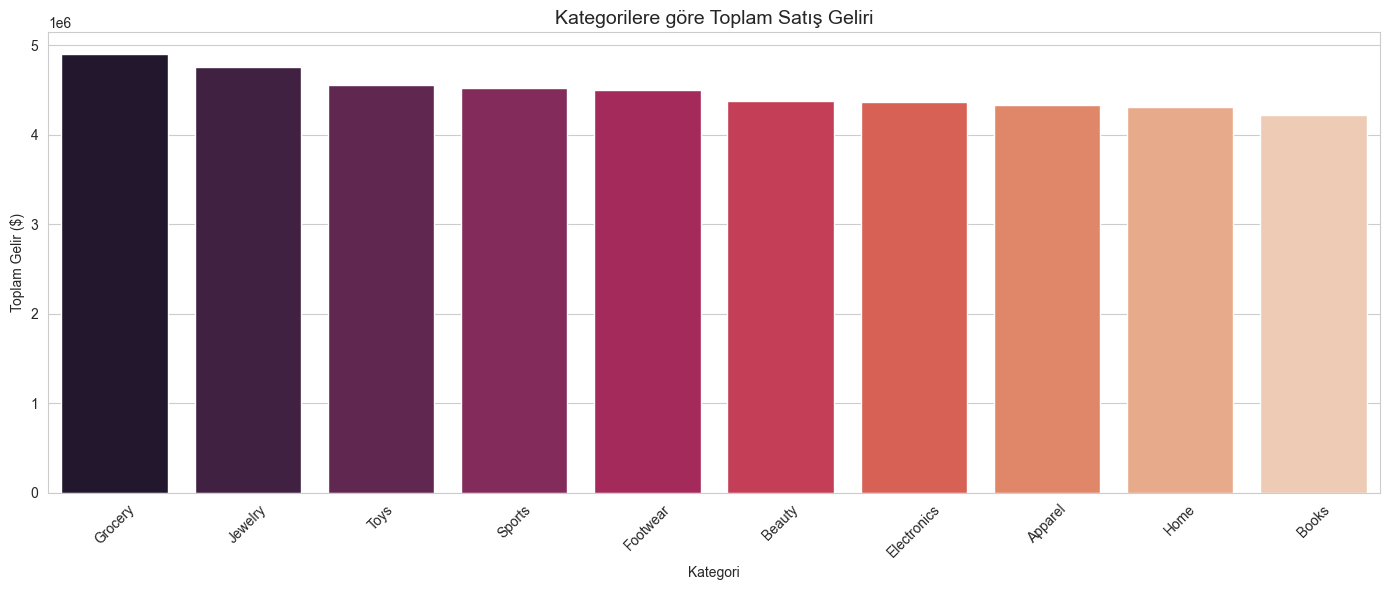

In [32]:
# Kategori bazlı toplam gelir grafiği
plt.figure(figsize=(14, 6))
sns.barplot(data=kategori_gelir, x='Kategori', y='Toplam Gelir', palette='rocket')
plt.title('Kategorilere göre Toplam Satış Geliri', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Toplam Gelir ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
# Kargo firması ve teslimat durumu çapraz tablosu - pivot table
pivot_tablo = pd.pivot_table(df, 
                             values='OrderID', 
                             index='Carrier', 
                             columns='DeliveryStatus', 
                             aggfunc='count',
                             fill_value=0) #fill_value ile eksik değerleri 0 ile dolduruyoruz

print("KARGO FİRMASI ve TESLİMAT DURUMU (PIVOT TABLE)")
pivot_tablo

KARGO FİRMASI ve TESLİMAT DURUMU (PIVOT TABLE)


DeliveryStatus,Late,OnTime
Carrier,,
DHL,31822,14254
FedEx,31458,14297
UPS,31665,14117
USPS,30274,14251


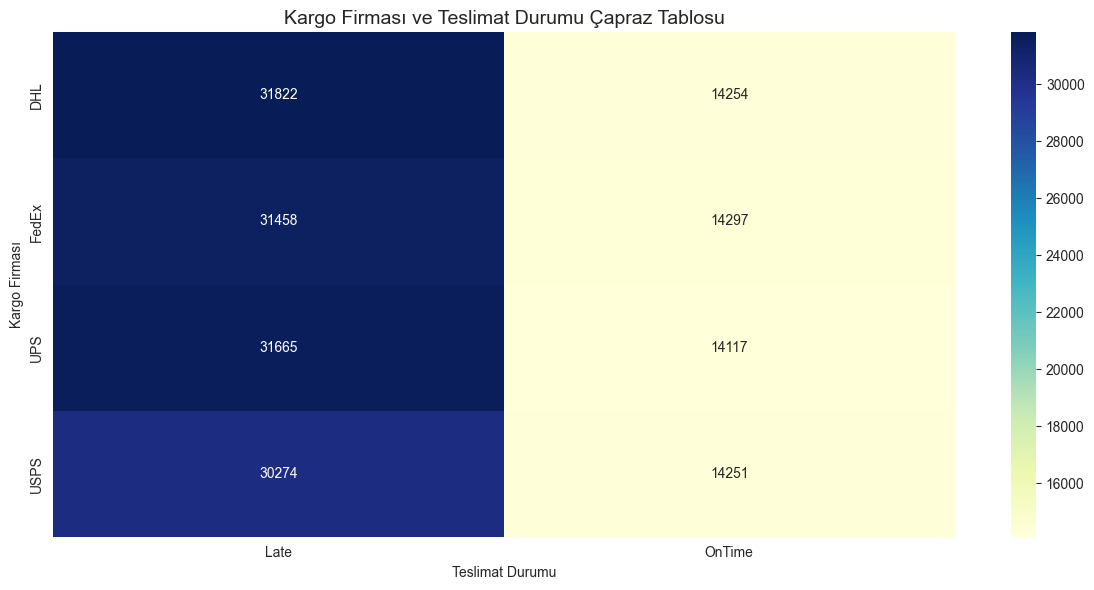

In [34]:
# Pivot table heatmap görselleştirmesi
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_tablo, annot=True, fmt='d', cmap='YlGnBu') # fmt='d' ile tam sayı formatında gösterim
plt.title('Kargo Firması ve Teslimat Durumu Çapraz Tablosu', fontsize=14) # Başlık
plt.xlabel('Teslimat Durumu') # X Başlık
plt.ylabel('Kargo Firması') # Y Başlık
plt.tight_layout()
plt.show()

# 5. İstatiksel Testler
### 5.1 Normallik Testi
Normal dağılım var mı yok mu sorusunu soracağım.

In [45]:
# Normallik testi - Shapiro-Wilk testi
# Büyük veri setlerinde örneklem alıyoruz
orneklem = df['LineRevenue$'].sample(1000, random_state=42)

stat, p_value = shapiro(orneklem)

print("SHAPIRO-WILK NORMALLIK TESTİ")
print(f"Test İstatistiği: {stat:.4f}")
print(f"P-değeri: {p_value:.4f}")
print()

alpha = 0.05
if p_value > alpha:
    print(f"P-değeri ({p_value:.4f}) > alpha ({alpha})")
    print("Sonuç:Normal bir Dağılım vardır.")
else:
    print(f"P-değeri ({p_value:.4f}) < alpha ({alpha})")
    print("Sonuç: Normal Dağılım Yok")

SHAPIRO-WILK NORMALLIK TESTİ
Test İstatistiği: 0.8929
P-değeri: 0.0000

P-değeri (0.0000) < alpha (0.05)
Sonuç: Normal Dağılım Yok


In [46]:
# Card ve PayPal ödeme tiplerine göre gelir karşılaştırması
card_gelir = df[df['PaymentType'] == 'Card']['LineRevenue$']
paypal_gelir = df[df['PaymentType'] == 'PayPal']['LineRevenue$']

stat, p_value = ttest_ind(card_gelir.sample(1000, random_state=42), 
                          paypal_gelir.sample(1000, random_state=42))

print("BAGIMSIZ ORNEKLEM T-TESTI")
print("Card vs PayPal Gelir Karşılaştırması")
print(f"Card Ortalama Gelir: ${card_gelir.mean():,.2f}")
print(f"PayPal Ortalama Gelir: ${paypal_gelir.mean():,.2f}")
print(f"T-istatistiği: {stat:.4f}")
print(f"P-değeri: {p_value:.4f}")
print()

alpha = 0.05
if p_value > alpha:
    print(f"Sonuç: İki grup arasında istatistiksel olarak anlamlı fark yoktur (p > {alpha}).")
else:
    print(f"Sonuç: İki grup arasında istatistiksel olarak anlamlı fark vardır (p < {alpha}).")

BAGIMSIZ ORNEKLEM T-TESTI
Card vs PayPal Gelir Karşılaştırması
Card Ortalama Gelir: $246.97
PayPal Ortalama Gelir: $242.18
T-istatistiği: -1.4036
P-değeri: 0.1606

Sonuç: İki grup arasında istatistiksel olarak anlamlı fark yoktur (p > 0.05).


In [47]:
# Kargo firmalarına göre kargo ücreti karşılaştırması (ANOVA)
kargo_firmalari = df['Carrier'].unique()
gruplar = [df[df['Carrier'] == kargo]['ShipCost$'].dropna() for kargo in kargo_firmalari]

stat, p_value = f_oneway(*gruplar)

print("TEK YÖNLÜ ANOVA TESTİ")
print("Kargo Firmalarına Göre Kargo Ücreti Karşılaştırması")
print("=" * 50)

for kargo in kargo_firmalari:
    ort = df[df['Carrier'] == kargo]['ShipCost$'].mean()
    print(f"{kargo} Ortalama Kargo Ücreti: ${ort:.2f}")

print(f"\nF-istatistiği: {stat:.4f}")
print(f"P-değeri: {p_value:.4f}")
print()

alpha = 0.05
if p_value > alpha:
    print(f"Sonuç: Gruplar arasında istatistiksel olarak anlamlı fark yoktur (p > {alpha}).")
else:
    print(f"Sonuç: En az iki grup arasında istatistiksel olarak anlamlı fark vardır (p < {alpha}).")

TEK YÖNLÜ ANOVA TESTİ
Kargo Firmalarına Göre Kargo Ücreti Karşılaştırması
FedEx Ortalama Kargo Ücreti: $11.06
UPS Ortalama Kargo Ücreti: $11.14
USPS Ortalama Kargo Ücreti: $11.15
DHL Ortalama Kargo Ücreti: $11.15

F-istatistiği: 1.7005
P-değeri: 0.1645

Sonuç: Gruplar arasında istatistiksel olarak anlamlı fark yoktur (p > 0.05).


In [49]:
# UnitPrice ve LineRevenue$ arasındaki korelasyon
korelasyon_katsayisi, p_value = pearsonr(df['UnitPrice'], df['LineRevenue$'])

print("PEARSON KORELASYON TESTİ")
print("Birim Fiyat ve Satış Geliri İlişkisi")
print("=" * 50)
print(f"Korelasyon Katsayısı (r): {korelasyon_katsayisi:.4f}")
print(f"P-değeri: {p_value:.4e}")
print()

# Korelasyon yorumu
if abs(korelasyon_katsayisi) >= 0.7:
    guc = "güçlü"
elif abs(korelasyon_katsayisi) >= 0.4:
    guc = "orta düzeyde"
else:
    guc = "zayıf"

yon = "pozitif" if korelasyon_katsayisi > 0 else "negatif"

print(f"Yorum: İki değişken arasında {guc} {yon} ilişki vardır.")

PEARSON KORELASYON TESTİ
Birim Fiyat ve Satış Geliri İlişkisi
Korelasyon Katsayısı (r): 0.7090
P-değeri: 0.0000e+00

Yorum: İki değişken arasında güçlü pozitif ilişki vardır.
